In [1]:
import pandas as pd
import numpy as np

import geopandas as gpd
from shapely.geometry import LineString

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Polygon as MplPolygon

from scipy.stats import gaussian_kde

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf

In [2]:
df = pd.read_csv("earthquakes_1900-2025_cleaned.csv")

In [3]:
df.head()

,datetime,date,time,latitude,longitude,depth,magnitude,distance_km,direction_text,bearing_deg,reference_full,reference_city,reference_province,location,source,region,region_encoded
0,01/06/1905 2:23,06/01/1905,2:23:33 am,18.895,120.203,15.0,6.80,61.0,NW,315.0,DAVILA,DAVILA,NaN,61 km NW of Davila,USGS,REGION I,3
1,11/12/1905 2:09,12/11/1905,2:09:59 am,13.445,125.858,15.0,6.80,123.0,NE,45.0,CABATUAN,CABATUAN,NaN,123 km NE of Cabatuan,USGS,REGION VI,10
2,10/10/1906 20:52,10/10/1906,8:52:38 pm,8.825,126.695,35.0,6.59,42.0,E,90.0,ARAS-ASAN,ARAS-ASAN,NaN,42 km E of Aras-asan,USGS,REGION VI,10
3,11/10/1906 13:10,10/11/1906,1:10:54 pm,10.078,123.560,15.0,6.48,5.0,SSW,202.5,MANTALONGON,MANTALONGON,NaN,5 km SSW of Mantalongon,USGS,REGION VII,11
4,10/07/1907 2:54,07/10/1907,2:54:59 am,15.152,121.796,15.0,6.82,24.0,N,0.0,PANUKULAN,PANUKULAN,NaN,24 km N of Panukulan,USGS,REGION IV-A,6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142487 entries, 0 to 142486
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   datetime            142487 non-null  object 
 1   date                142487 non-null  object 
 2   time                142487 non-null  object 
 3   latitude            142462 non-null  float64
 4   longitude           142462 non-null  float64
 5   depth               142441 non-null  float64
 6   magnitude           142487 non-null  float64
 7   distance_km         141901 non-null  float64
 8   direction_text      140573 non-null  object 
 9   bearing_deg         140570 non-null  float64
 10  reference_full      141833 non-null  object 
 11  reference_city      138198 non-null  object 
 12  reference_province  119105 non-null  object 
 13  location            142487 non-null  object 
 14  source              142487 non-null  object 
 15  region              142487 non-nul

In [5]:
df.describe()

,latitude,longitude,depth,magnitude,distance_km,bearing_deg,region_encoded
count,142462.000000,142462.000000,142441.000000,142487.000000,141901.000000,140570.000000,142487.000000
mean,10.766844,124.136376,37.182156,2.881097,40.055682,160.133905,10.703398
std,4.134825,2.538286,57.259920,1.060834,50.963644,95.635552,4.856588
min,1.780000,10.560000,0.000000,0.000000,0.000000,-656.000000,0.000000
25%,7.620000,121.538000,10.000000,2.100000,10.000000,83.000000,6.000000
50%,9.890000,125.000000,24.000000,2.600000,21.000000,136.000000,12.000000
75%,13.730000,126.318000,35.000000,3.500000,49.000000,243.000000,15.000000
max,24.938000,163.630000,1068.000000,7.700000,779.000000,765.000000,17.000000


In [6]:
bins = np.arange(0, 11, 1)           # [0,1,2,...,10]
labels = np.arange(0, 10)            # 0->0-1, 1->1-2, ..., 9->9-10
df['magnitude_class'] = pd.cut(df['magnitude'], bins=bins, labels=labels, include_lowest=True)
df['magnitude_class'] = df['magnitude_class'].astype(int)

In [7]:
df["datetime"] = pd.to_datetime(df["datetime"], format="mixed", dayfirst=True, errors="coerce")

In [8]:
df['datetime'] = pd.to_datetime(df['datetime'])

# Extract features
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month

# 3-year interval (e.g., 2017–2019, 2020–2022)
df['year_3yr'] = (df['year'] // 3) * 3

# Decade
df['decade'] = (df['year'] // 10) * 10

In [9]:
df.head()

,datetime,date,time,latitude,longitude,depth,magnitude,distance_km,direction_text,bearing_deg,...,reference_province,location,source,region,region_encoded,magnitude_class,year,month,year_3yr,decade
0,1905-06-01 02:23:00,06/01/1905,2:23:33 am,18.895,120.203,15.0,6.80,61.0,NW,315.0,...,NaN,61 km NW of Davila,USGS,REGION I,3,6,1905,6,1905,1900
1,1905-12-11 02:09:00,12/11/1905,2:09:59 am,13.445,125.858,15.0,6.80,123.0,NE,45.0,...,NaN,123 km NE of Cabatuan,USGS,REGION VI,10,6,1905,12,1905,1900
2,1906-10-10 20:52:00,10/10/1906,8:52:38 pm,8.825,126.695,35.0,6.59,42.0,E,90.0,...,NaN,42 km E of Aras-asan,USGS,REGION VI,10,6,1906,10,1905,1900
3,1906-10-11 13:10:00,10/11/1906,1:10:54 pm,10.078,123.560,15.0,6.48,5.0,SSW,202.5,...,NaN,5 km SSW of Mantalongon,USGS,REGION VII,11,6,1906,10,1905,1900
4,1907-07-10 02:54:00,07/10/1907,2:54:59 am,15.152,121.796,15.0,6.82,24.0,N,0.0,...,NaN,24 km N of Panukulan,USGS,REGION IV-A,6,6,1907,7,1905,1900


## Exploratory Data Analysis

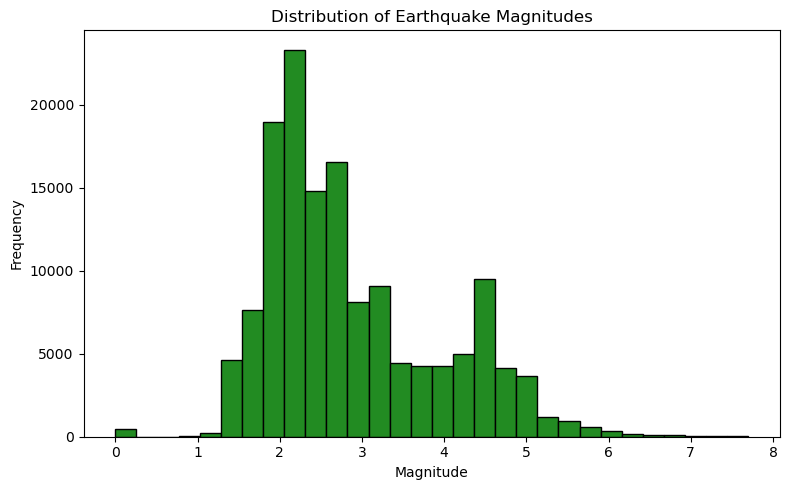

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df['magnitude'], bins=30, edgecolor='black', color='forestgreen')
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.title("Distribution of Earthquake Magnitudes")
plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Distribution of Earthquake Magnitudes.png", dpi=300, bbox_inches='tight')
plt.show()

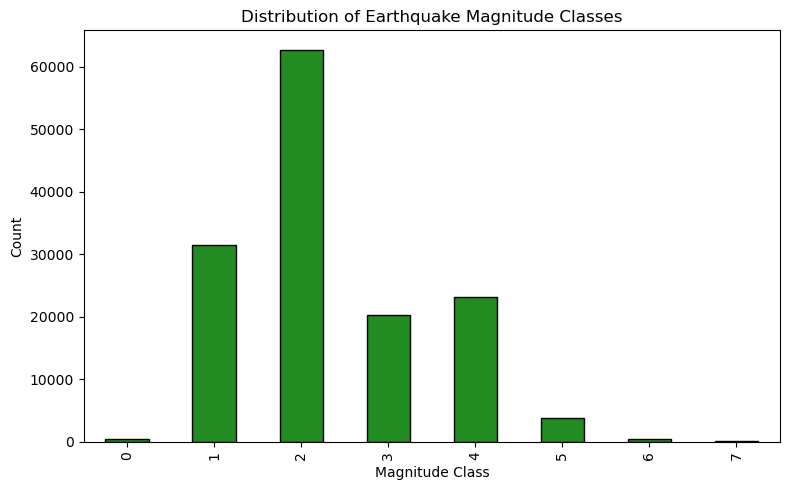

In [11]:
plt.figure(figsize=(8,5))
df['magnitude_class'].value_counts().sort_index().plot(
    kind='bar',
    color='forestgreen',
    edgecolor='black'
)
plt.xlabel("Magnitude Class")
plt.ylabel("Count")
plt.title("Distribution of Earthquake Magnitude Classes")
plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Distribution of Earthquake Magnitude Classes.png", dpi=300, bbox_inches='tight')

plt.show()

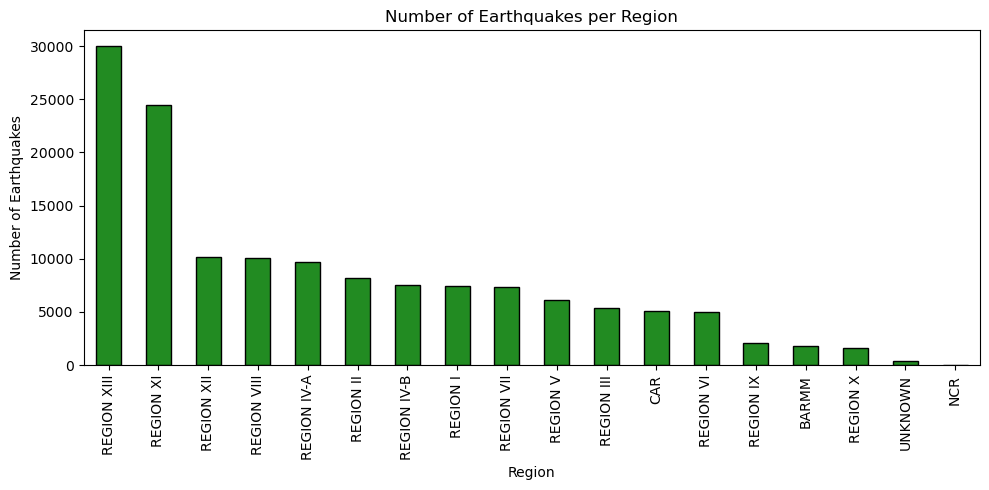

In [12]:
plt.figure(figsize=(10,5))
df['region'].value_counts().plot(
    kind='bar',
    color='forestgreen',
    edgecolor='black'
)
plt.xlabel("Region")
plt.ylabel("Number of Earthquakes")
plt.title("Number of Earthquakes per Region")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Number of Earthquakes per Region.png", dpi=300, bbox_inches='tight')

plt.show()

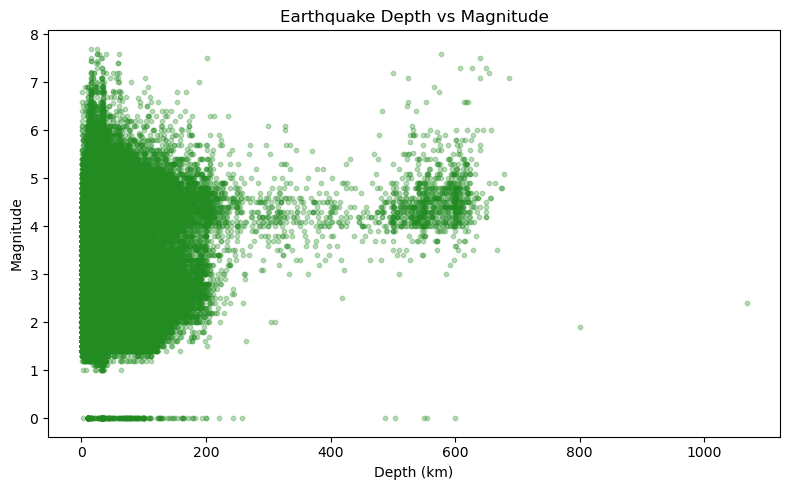

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['depth'],
    df['magnitude'],
    alpha=0.3,
    s=10,
    color='forestgreen'
)
plt.xlabel("Depth (km)")
plt.ylabel("Magnitude")
plt.title("Earthquake Depth vs Magnitude")
plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Earthquake Depth vs Magnitude.png", dpi=300, bbox_inches='tight')

plt.show()

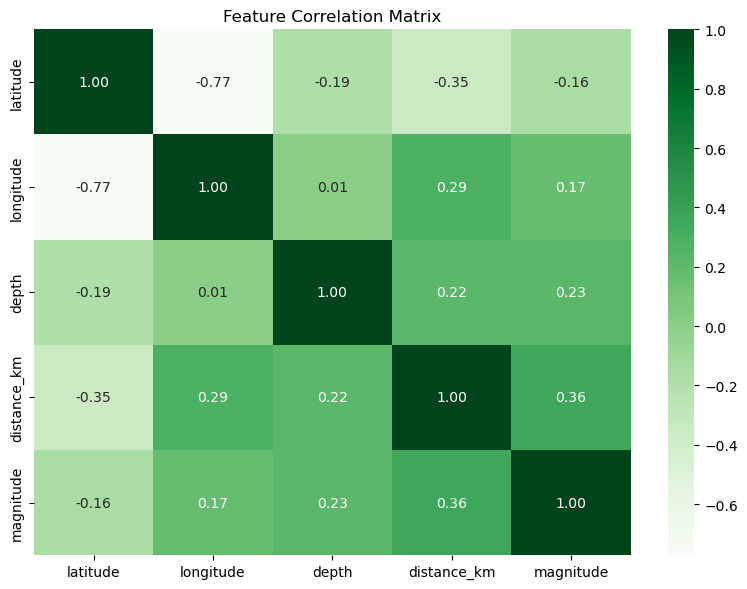

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['latitude', 'longitude', 'depth', 'distance_km', 'magnitude']].corr(),
    annot=True,
    cmap='Greens',
    fmt=".2f"
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Feature Correlation Matrix.png", dpi=300, bbox_inches='tight')

plt.show()

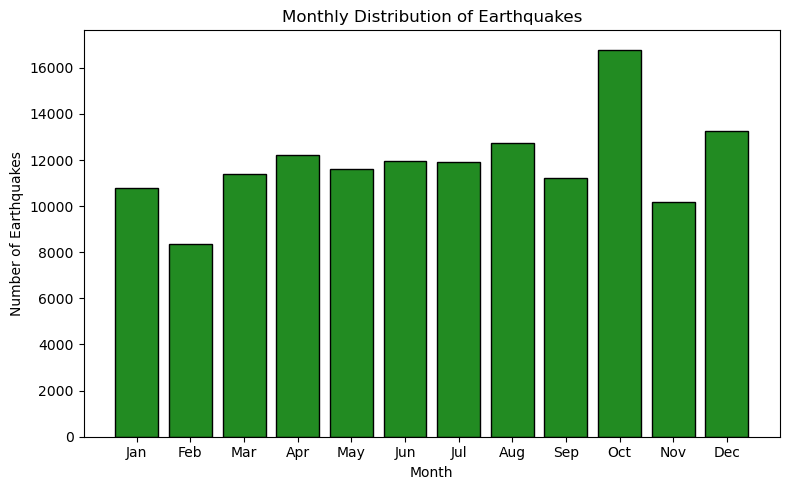

In [15]:
plt.figure(figsize=(8,5))

month_counts = df.groupby("month").size()

plt.bar(
    month_counts.index,
    month_counts.values,
    color="forestgreen",
    edgecolor="black"
)

plt.xlabel("Month")
plt.ylabel("Number of Earthquakes")
plt.title("Monthly Distribution of Earthquakes")

plt.xticks(
    ticks=range(1,13),
    labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Monthly Distribution of Earthquakes.png", dpi=300, bbox_inches='tight')

plt.show()

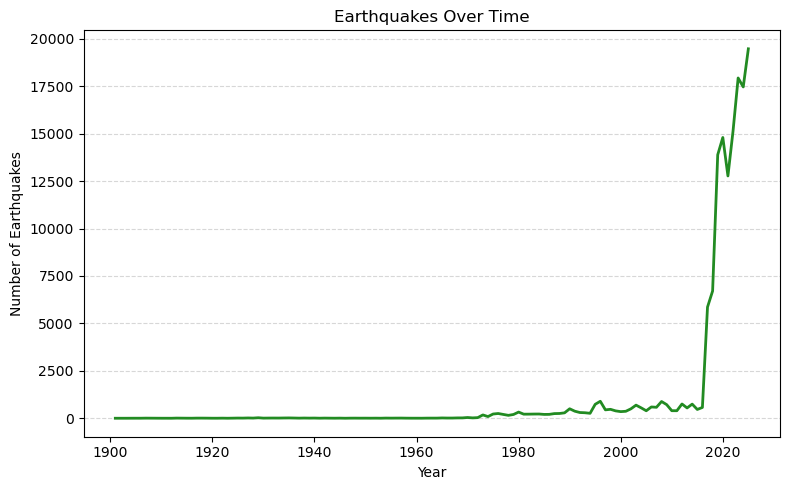

In [16]:
plt.figure(figsize=(8,5))

year_counts = df.groupby("year").size()

plt.plot(
    year_counts.index,
    year_counts.values,
    color="forestgreen",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquakes Over Time")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Earthquakes Over Time.png", dpi=300, bbox_inches='tight')

plt.show()

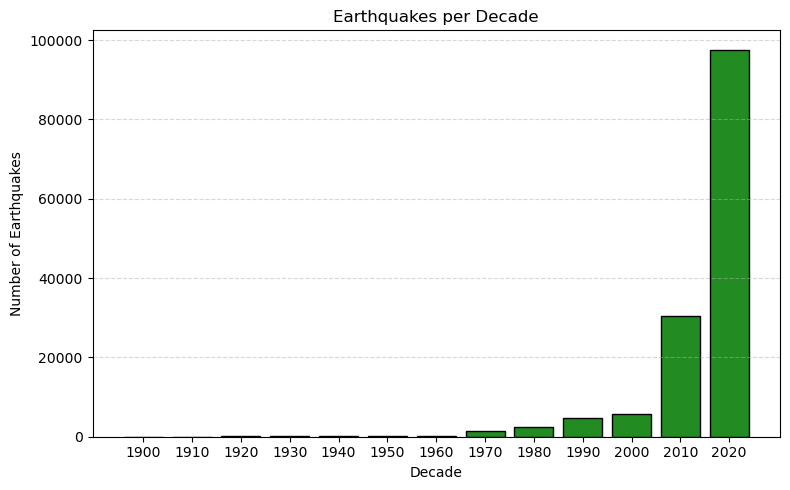

In [17]:
plt.figure(figsize=(8,5))

decade_counts = df.groupby("decade").size()

plt.bar(
    decade_counts.index.astype(int).astype(str),  # x-axis as string for readability
    decade_counts.values,
    color="forestgreen",
    edgecolor="black"
)

plt.xlabel("Decade")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquakes per Decade")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Earthquakes per Decade.png", dpi=300, bbox_inches='tight')

plt.show()

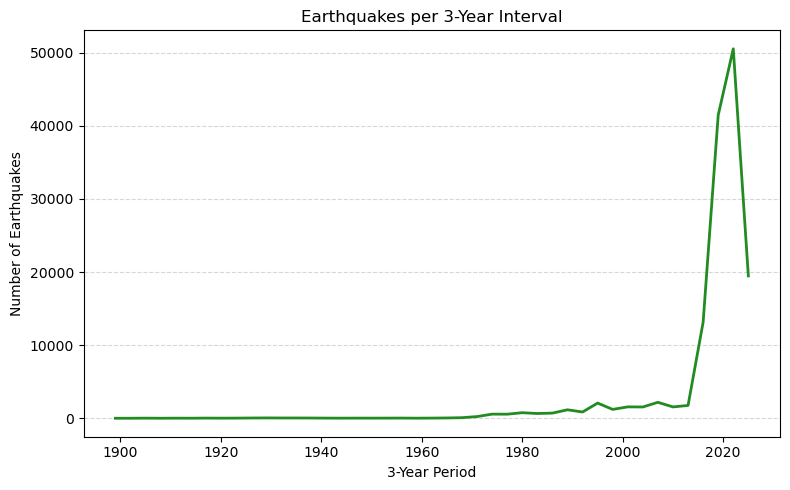

In [18]:
plt.figure(figsize=(8,5))

# Group by 3-year interval
df["year_group_3"] = (df["year"] // 3) * 3
interval_counts = df.groupby("year_group_3").size()

plt.plot(
    interval_counts.index,
    interval_counts.values,
    color="forestgreen",
    linewidth=2
)

plt.xlabel("3-Year Period")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquakes per 3-Year Interval")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Earthquakes per 3-Year Interval.png", dpi=300, bbox_inches='tight')

plt.show()

### Time-Series Analysis

In [19]:
forest_green = "#228B22"

# Ensure datetime column is in datetime format
df['datetime'] = pd.to_datetime(df['datetime'])
df_ts = df.set_index('datetime')

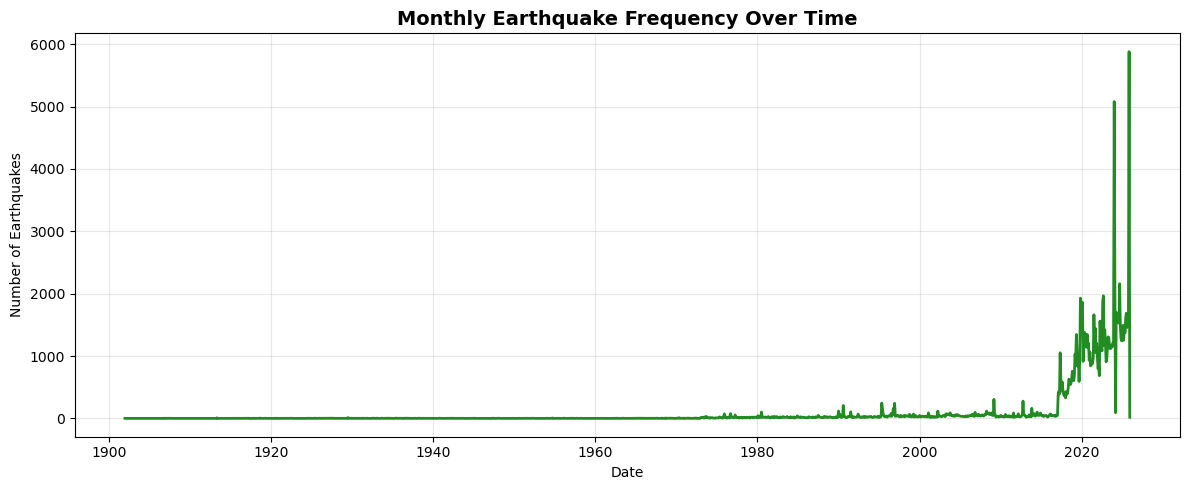

In [20]:
monthly_counts = df_ts.resample('ME').size()  # 'ME' = month end
plt.figure(figsize=(12,5))
plt.plot(monthly_counts, color=forest_green, linewidth=2)
plt.title("Monthly Earthquake Frequency Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Number of Earthquakes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Monthly Earthquake Frequency Over Time.png", dpi=300, bbox_inches='tight')

plt.show()

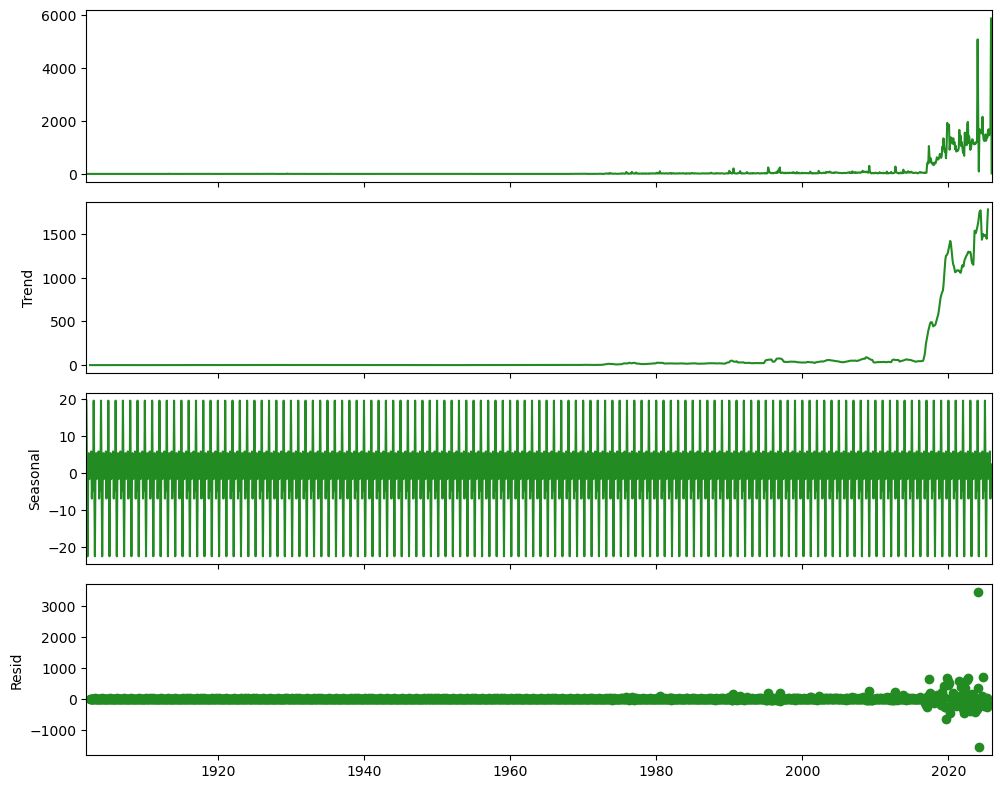

In [21]:
decomp = seasonal_decompose(monthly_counts, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(10,8)

# Apply forest green to trend and seasonal lines
for ax in fig.axes:
    for line in ax.get_lines():
        line.set_color(forest_green)

plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Seasonal Decompose.png", dpi=300, bbox_inches='tight')

plt.show()

<Figure size 800x500 with 0 Axes>

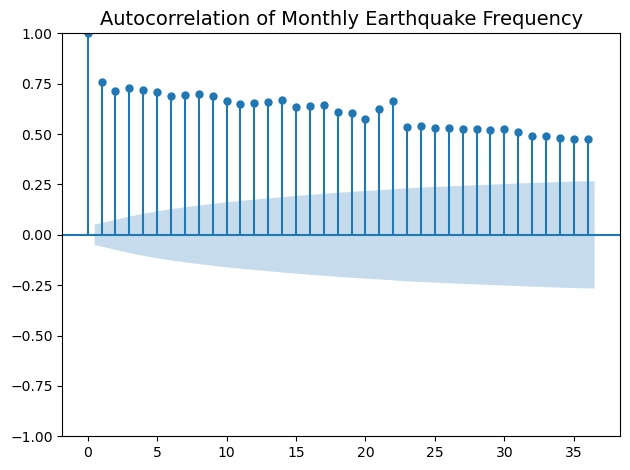

In [22]:
plt.figure(figsize=(8,5))
plot_acf(monthly_counts, lags=36)
plt.title("Autocorrelation of Monthly Earthquake Frequency", fontsize=14)
plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Autocorrelation of Monthly Earthquake Frequency.png", dpi=300, bbox_inches='tight')

plt.show()

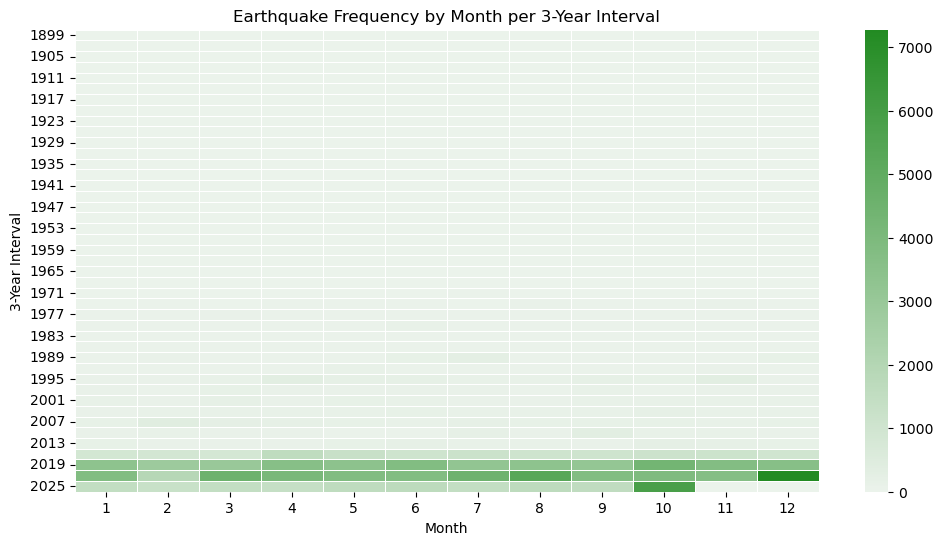

In [23]:
month_3yr = df.groupby(['year_3yr', 'month']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(
    month_3yr,
    cmap=sns.light_palette(forest_green, as_cmap=True),
    linewidths=0.5
)

plt.title("Earthquake Frequency by Month per 3-Year Interval")
plt.xlabel("Month")
plt.ylabel("3-Year Interval")
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Earthquake Frequency by Month per 3-Year Interval.png", dpi=300, bbox_inches='tight')

plt.show()

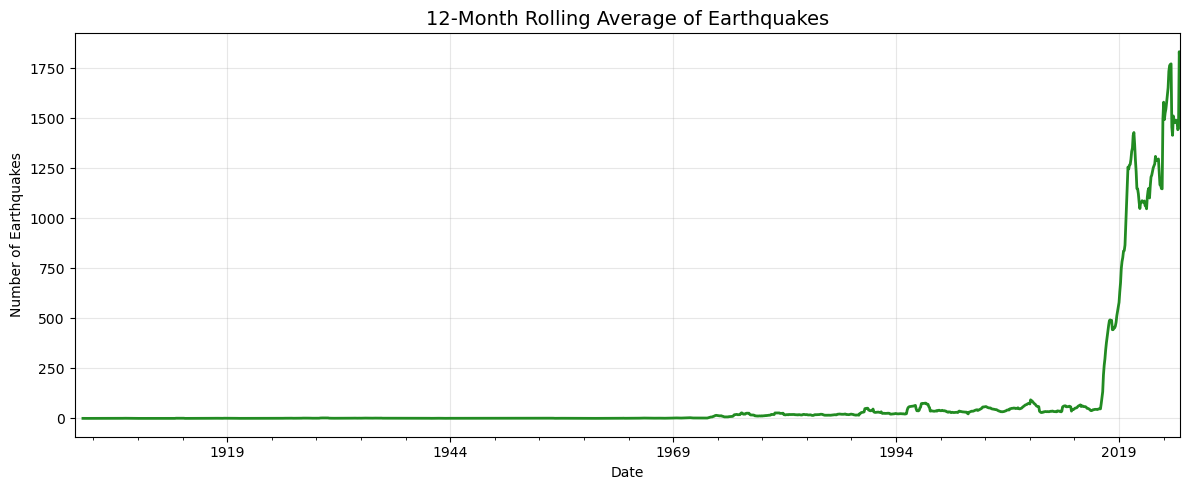

In [24]:
plt.figure(figsize=(12,5))
monthly_counts.rolling(window=12).mean().plot(color=forest_green, linewidth=2)
plt.title("12-Month Rolling Average of Earthquakes", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Earthquakes")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\12-Month Rolling Average of Earthquakes.png", dpi=300, bbox_inches='tight')

plt.show()

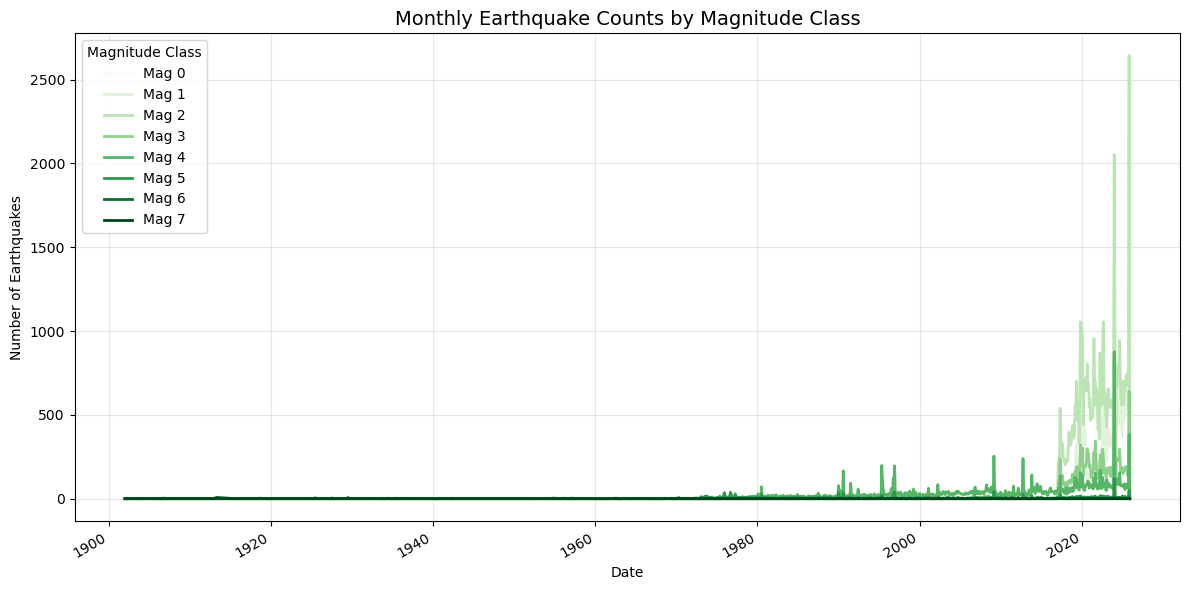

In [25]:
mag_counts = df_ts.groupby([pd.Grouper(freq='ME'), 'magnitude_class']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
mag_counts.plot(ax=plt.gca(), linewidth=2, colormap='Greens')
plt.title("Monthly Earthquake Counts by Magnitude Class", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Earthquakes")
plt.legend(title="Magnitude Class", labels=[f"Mag {i}" for i in mag_counts.columns])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Monthly Earthquake Counts by Magnitude Class.png", dpi=300, bbox_inches='tight')

plt.show()

C:\Users\Nathalya Peralta\AppData\Local\Temp\ipykernel_3600\3609581837.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('tab20')  # categorical colormap for up to 20 regions


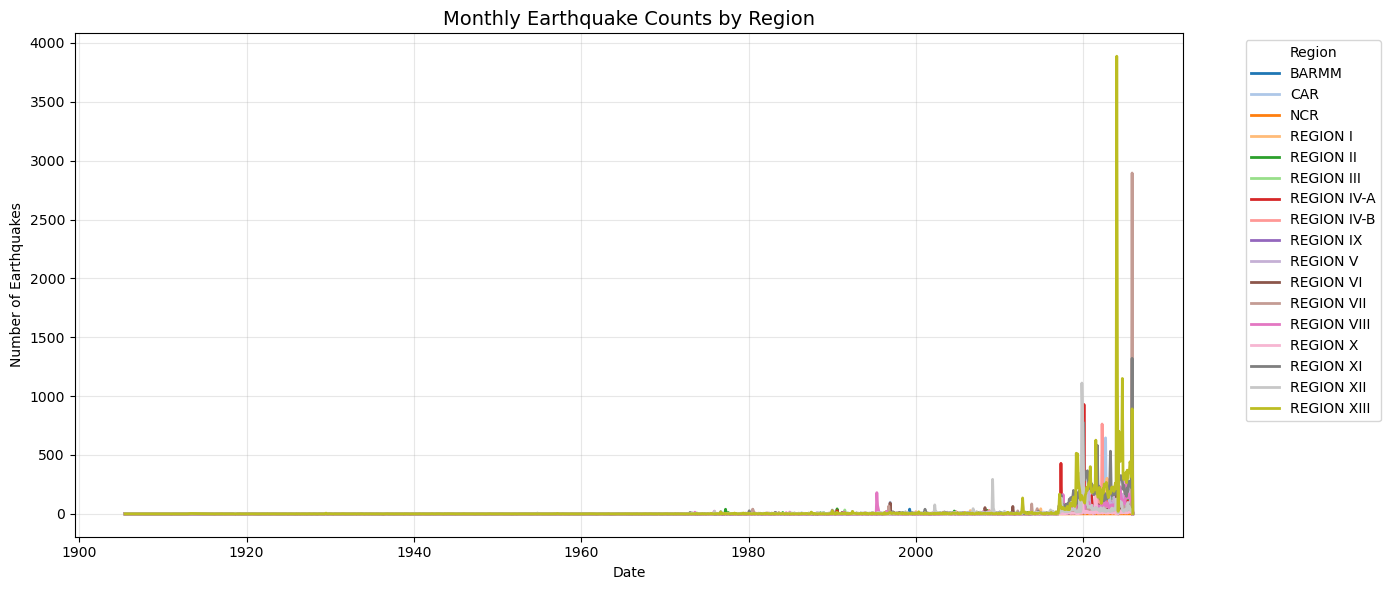

In [26]:
if 'region' in df.columns:
    # Filter out UNKNOWN region
    df_region = df_ts[df_ts['region'] != 'UNKNOWN']
    
    # Group by month and region
    region_monthly = df_region.groupby([pd.Grouper(freq='ME'), 'region']).size().unstack(fill_value=0)
    
    plt.figure(figsize=(14,6))
    
    # Use a distinct color for each region
    from matplotlib.cm import get_cmap
    cmap = get_cmap('tab20')  # categorical colormap for up to 20 regions
    colors = [cmap(i) for i in range(len(region_monthly.columns))]
    
    # Plot each region with its own color
    for i, region in enumerate(region_monthly.columns):
        plt.plot(region_monthly.index, region_monthly[region], 
                 label=region, color=colors[i], linewidth=2)
    
    plt.title("Monthly Earthquake Counts by Region", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Number of Earthquakes")
    plt.legend(title="Region", bbox_to_anchor=(1.05,1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\Monthly Earthquake Counts by Region.png", dpi=300, bbox_inches='tight')

    plt.show()

### Geospatial Analysis

In [27]:
df.columns = [c.strip().lower() for c in df.columns]

df = df.dropna(subset=["latitude", "longitude"]).copy()

if "magnitude" in df.columns:
    df = df[(df["magnitude"] >= 0) & (df["magnitude"] <= 10)]

if "depth" in df.columns:
    df = df[(df["depth"] >= 0) & (df["depth"] <= 700)]

df = df[
    (df["latitude"] >= 2.0) &
    (df["latitude"] <= 22.5) &
    (df["longitude"] >= 116.0) &
    (df["longitude"] <= 128.0)
].copy()

print("Rows after cleaning:", len(df))

Rows after cleaning: 142196


In [28]:
earthquakes = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

In [29]:
gdf_map = gpd.read_file("gadm41_PHL_1.json").to_crs(epsg=4326)

philippines = gdf_map.dissolve()

In [30]:
volcano_data = [
    ("Babuyan Claro", 19.52408, 121.95005),
    ("Banahaw", 14.06038, 121.48803),
    ("Biliran", 11.52333, 124.53500),
    ("Bulusan", 12.76900, 124.05500),
    ("Cagua", 18.22200, 122.12300),
    ("Camiguin de Babuyanes", 18.83100, 121.85600),
    ("Didicas", 19.07700, 122.20200),
    ("Hibok-Hibok", 9.20400, 124.67300),
    ("Iraya", 20.46900, 122.01000),
    ("Kanlaon", 10.41200, 123.13200),
    ("Leonard Kniaseff", 7.18000, 126.10000),
    ("Makaturing", 7.64700, 124.26900),
    ("Matutum", 6.37100, 125.06800),
    ("Mayon", 13.25700, 123.68500),
    ("Musuan", 7.87700, 125.06800),
    ("Parker", 6.11300, 124.89200),
    ("Pinatubo", 15.14200, 120.34900),
    ("Ragang", 7.68700, 124.50700),
    ("Smith", 19.53900, 121.91300),
    ("Taal", 14.00200, 120.99300)
]

volcano_df = pd.DataFrame(volcano_data, columns=["name", "latitude", "longitude"])

volcanoes = gpd.GeoDataFrame(
    volcano_df,
    geometry=gpd.points_from_xy(volcano_df["longitude"], volcano_df["latitude"]),
    crs="EPSG:4326"
)

In [31]:
trench_segments = {
    # Manila Trench
    "MT1": [(119.45, 18.9), (120.10, 20.8)],
    "MT2": [(119.10, 16.4), (119.10, 18.8)],
    "MT3": [(119.10, 14.1), (119.10, 16.4)],
    "MT4": [(119.25, 14.0), (120.10, 12.7)],

    # East Luzon Trough
    "ELT": [(122.70, 15.4), (123.40, 18.7)],

    # Philippine Trench
    "PT1": [(124.20, 14.9), (124.80, 13.0)],
    "PT2": [(124.80, 13.0), (125.30, 11.8)],
    "PT3": [(125.30, 11.8), (125.70, 10.2)],
    "PT4": [(125.70, 10.2), (125.95, 8.4)],
    "PT5": [(125.95, 8.4), (126.00, 6.7)],
    "PT6": [(126.00, 6.7), (127.00, 4.3)],

    # Negros Trench
    "NT1": [(121.55, 9.3), (122.15, 10.9)],
    "NT2": [(121.00, 8.3), (121.75, 9.45)],

    # Sulu Trench
    "ST1": [(120.00, 7.3), (121.25, 8.8)],
    "ST2": [(119.00, 6.0), (120.30, 7.2)],

    # Cotabato Trench
    "CT1": [(124.00, 5.8), (124.85, 4.7)],
    "CT2": [(123.60, 7.3), (123.70, 5.8)],
}

trench_gdf = gpd.GeoDataFrame(
    [{"name": name, "geometry": LineString(coords)} for name, coords in trench_segments.items()],
    crs="EPSG:4326"
)

In [32]:
segment_side_map = {
    "MT1": "west",
    "MT2": "west",
    "MT3": "west",
    "MT4": "southwest",
    "ELT": "east",
    "PT1": "east",
    "PT2": "east",
    "PT3": "east",
    "PT4": "east",
    "PT5": "east",
    "PT6": "east",
    "NT1": "west",
    "NT2": "west",
    "ST1": "south",
    "ST2": "southwest",
    "CT1": "southwest",
    "CT2": "west",
}

In [33]:
def unit_direction(side):
    dirs = {
        "east": (1.0, 0.0),
        "west": (-1.0, 0.0),
        "north": (0.0, 1.0),
        "south": (0.0, -1.0),
        "northeast": (1.0, 1.0),
        "northwest": (-1.0, 1.0),
        "southeast": (1.0, -1.0),
        "southwest": (-1.0, -1.0),
    }
    x, y = dirs.get(side, (1.0, 0.0))
    n = np.hypot(x, y)
    return x / n, y / n

def build_segment_block(line, width=0.20):
    x1, y1 = line.coords[0]
    x2, y2 = line.coords[-1]

    dx = x2 - x1
    dy = y2 - y1
    norm = np.hypot(dx, dy)
    if norm == 0:
        return None

    px = -dy / norm
    py = dx / norm
    half = width / 2

    p1 = (x1 + px * half, y1 + py * half)
    p2 = (x2 + px * half, y2 + py * half)
    p3 = (x2 - px * half, y2 - py * half)
    p4 = (x1 - px * half, y1 - py * half)

    return [p1, p2, p3, p4]

def add_segment_block(ax, line, facecolor="#8e24aa", edgecolor="#ff1744", width=0.20, lw=4):
    rect = build_segment_block(line, width=width)
    if rect is None:
        return
    patch = MplPolygon(
        rect,
        closed=True,
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=lw,
        joinstyle="miter",
        zorder=4
    )
    ax.add_patch(patch)

def add_segment_teeth(ax, line, side="east", spacing=0.34, tooth_len=0.15, tooth_width=0.10,
                      color="#d500f9"):
    total_length = line.length
    if total_length <= spacing:
        return

    nx, ny = unit_direction(side)
    distances = np.arange(spacing, total_length, spacing)

    for d in distances:
        p = line.interpolate(d)

        d1 = max(d - 0.01, 0)
        d2 = min(d + 0.01, total_length)

        p1 = line.interpolate(d1)
        p2 = line.interpolate(d2)

        dx = p2.x - p1.x
        dy = p2.y - p1.y
        tangent_norm = np.hypot(dx, dy)
        if tangent_norm == 0:
            continue

        tx = dx / tangent_norm
        ty = dy / tangent_norm

        base_left = (
            p.x - tx * (tooth_width / 2),
            p.y - ty * (tooth_width / 2)
        )
        base_right = (
            p.x + tx * (tooth_width / 2),
            p.y + ty * (tooth_width / 2)
        )
        tip = (
            p.x + nx * tooth_len,
            p.y + ny * tooth_len
        )

        tri = MplPolygon(
            [base_left, base_right, tip],
            closed=True,
            facecolor=color,
            edgecolor=color,
            linewidth=0.5,
            zorder=5
        )
        ax.add_patch(tri)

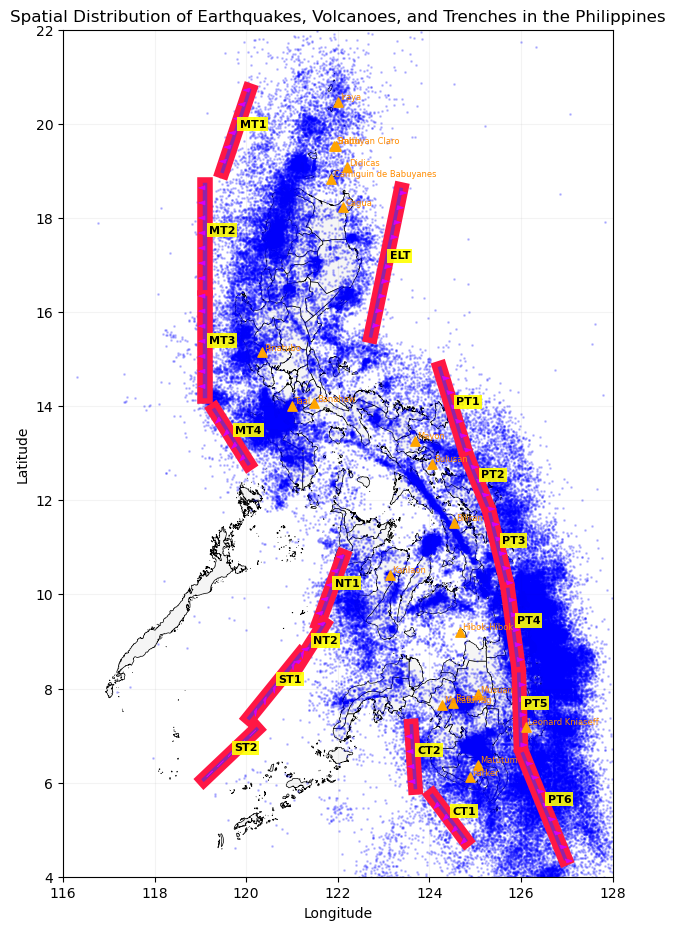

In [34]:
fig, ax = plt.subplots(figsize=(8, 11))

gdf_map.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="black",
    linewidth=0.5,
    zorder=1
)

earthquakes.plot(
    ax=ax,
    color="blue",
    markersize=1.0,
    alpha=0.20,
    zorder=2
)

volcanoes.plot(
    ax=ax,
    color="orange",
    marker="^",
    markersize=45,
    zorder=6
)

for _, row in trench_gdf.iterrows():
    geom = row.geometry
    seg = row["name"]

    add_segment_block(
        ax=ax,
        line=geom,
        facecolor="#8e24aa",
        edgecolor="#ff1744",
        width=0.20,
        lw=4
    )

    add_segment_teeth(
        ax=ax,
        line=geom,
        side=segment_side_map.get(seg, "east"),
        spacing=0.32,
        tooth_len=0.14,
        tooth_width=0.09,
        color="#d500f9"
    )

for _, row in trench_gdf.iterrows():
    mid = row.geometry.interpolate(0.5, normalized=True)
    ax.text(
        mid.x + 0.08,
        mid.y + 0.08,
        row["name"],
        fontsize=8,
        weight="bold",
        color="black",
        bbox=dict(facecolor="yellow", edgecolor="none", alpha=0.9, pad=1.5),
        zorder=7
    )

for _, row in volcanoes.iterrows():
    ax.text(
        row.geometry.x + 0.05,
        row.geometry.y + 0.05,
        row["name"],
        fontsize=6,
        color="darkorange",
        zorder=7
    )

ax.set_title("Spatial Distribution of Earthquakes, Volcanoes, and Trenches in the Philippines")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(116, 128)
ax.set_ylim(4, 22)
ax.grid(alpha=0.15)

plt.show()

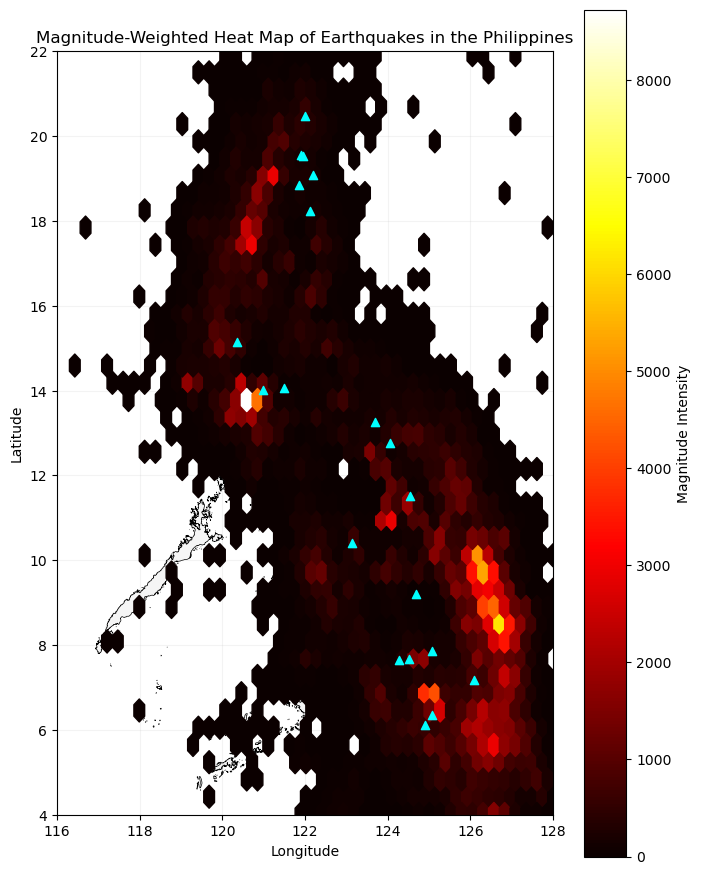

In [35]:
fig, ax = plt.subplots(figsize=(8, 11))

gdf_map.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="black",
    linewidth=0.5,
    zorder=1
)

hb = ax.hexbin(
    earthquakes["longitude"],
    earthquakes["latitude"],
    C=earthquakes["magnitude"],
    reduce_C_function=np.sum,   
    gridsize=45,
    mincnt=1,
    cmap="hot",
    zorder=2
)

volcanoes.plot(
    ax=ax,
    marker="^",
    color="cyan",
    markersize=35,
    zorder=4
)

cb = plt.colorbar(hb, ax=ax)
cb.set_label("Magnitude Intensity")

ax.set_title("Magnitude-Weighted Heat Map of Earthquakes in the Philippines")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(116, 128)
ax.set_ylim(4, 22)
ax.set_ylim(4, 22)
ax.grid(alpha=0.15)

plt.show()

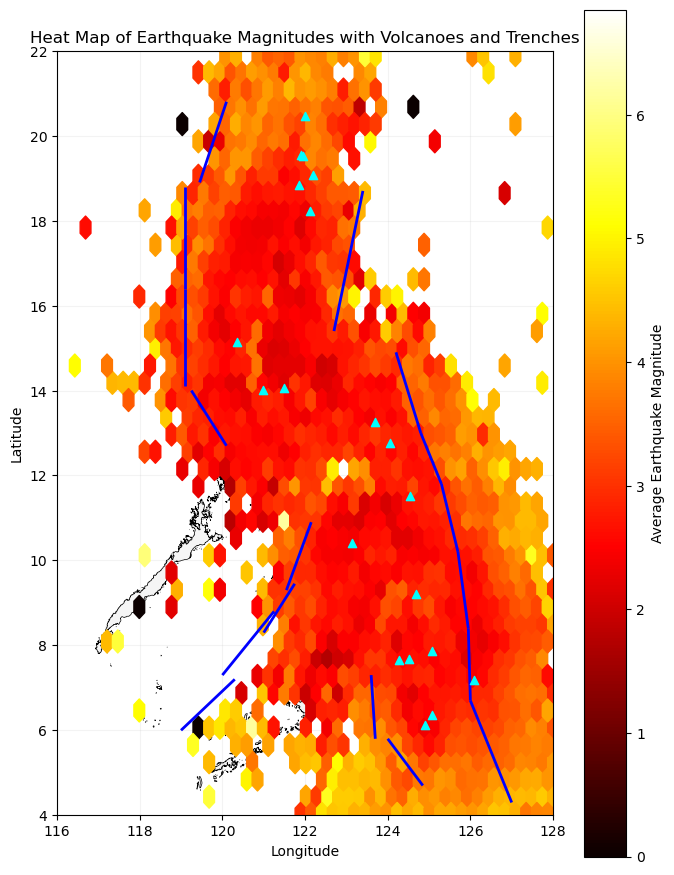

In [36]:
fig, ax = plt.subplots(figsize=(8, 11))

gdf_map.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="black",
    linewidth=0.5,
    zorder=1
)

hb = ax.hexbin(
    earthquakes["longitude"],
    earthquakes["latitude"],
    C=earthquakes["magnitude"],
    reduce_C_function=np.mean,
    gridsize=45,
    mincnt=1,
    cmap="hot",
    zorder=2
)

trench_gdf.plot(
    ax=ax,
    linewidth=2,
    color="blue",
    zorder=3
)

volcanoes.plot(
    ax=ax,
    marker="^",
    color="cyan",
    markersize=35,
    zorder=4
)

cb = plt.colorbar(hb, ax=ax)
cb.set_label("Average Earthquake Magnitude")

ax.set_title("Heat Map of Earthquake Magnitudes with Volcanoes and Trenches")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(116, 128)
ax.set_ylim(4, 22)
ax.grid(alpha=0.15)

plt.show()

In [37]:
trench_lines = trench_gdf.copy()

In [38]:
metric_crs = "EPSG:3857"

earthquakes_m = earthquakes.to_crs(metric_crs)
volcanoes_m = volcanoes.to_crs(metric_crs)
trenches_m = trench_gdf.to_crs(metric_crs)

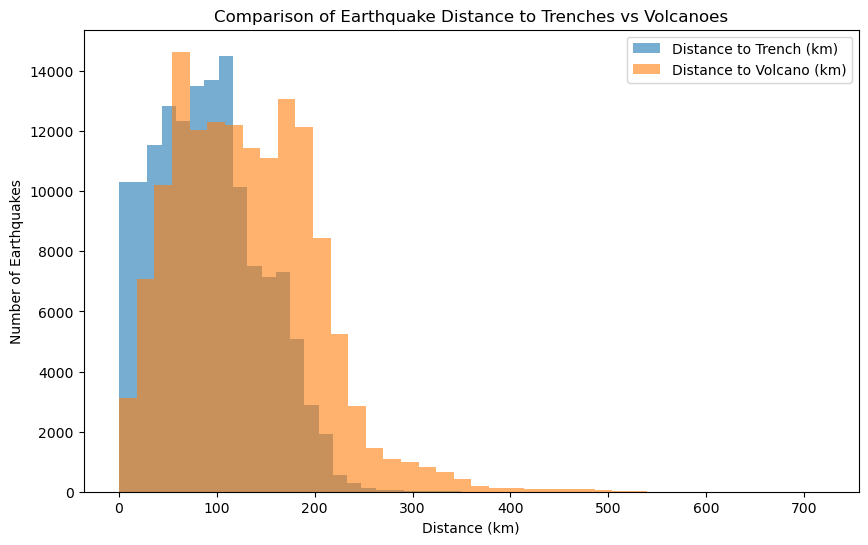

In [39]:
earthquakes_m["distance_to_volcano_km"] = earthquakes_m.geometry.apply(
    lambda x: volcanoes_m.distance(x).min() / 1000
)

earthquakes_m["distance_to_trench_km"] = earthquakes_m.geometry.apply(
    lambda x: trenches_m.distance(x).min() / 1000
)

earthquakes_m[["distance_to_volcano_km", "distance_to_trench_km"]].head()

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    earthquakes_m["distance_to_trench_km"],
    bins=40,
    alpha=0.6,
    label="Distance to Trench (km)"
)

ax.hist(
    earthquakes_m["distance_to_volcano_km"],
    bins=40,
    alpha=0.6,
    label="Distance to Volcano (km)"
)

ax.set_title("Comparison of Earthquake Distance to Trenches vs Volcanoes")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Number of Earthquakes")
ax.legend()
plt.show()

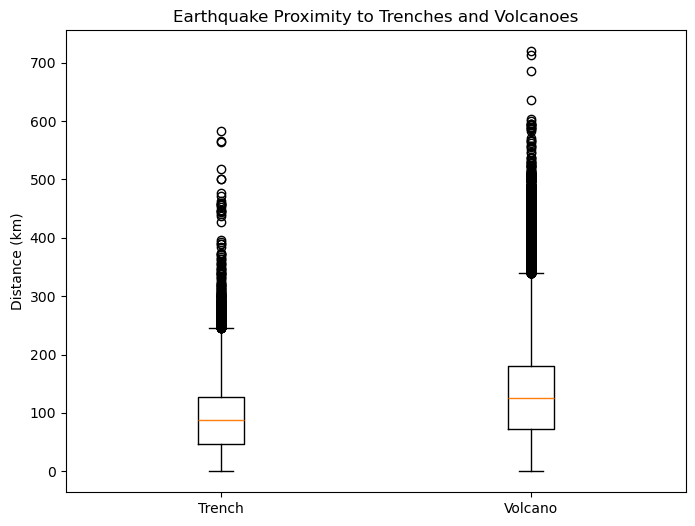

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot([
    earthquakes_m["distance_to_trench_km"].dropna(),
    earthquakes_m["distance_to_volcano_km"].dropna()
], labels=["Trench", "Volcano"])

ax.set_title("Earthquake Proximity to Trenches and Volcanoes")
ax.set_ylabel("Distance (km)")
plt.show()

### Train-Test Split

In [41]:
features = ["latitude", "longitude", "depth", "distance_km", "bearing_deg", "region_encoded"]
target = "magnitude_class"

X = df[features]
y = df[target].values

In [42]:
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

In [43]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [44]:
sss = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

In [45]:
models = {
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [46]:
def run_model(name, model, use_scaled=False, max_train_samples=None):
    """
    Train and evaluate a model across stratified splits.

    Returns:
        acc_list, f1w_list, f1m_list, precw_list, precm_list, recw_list, recm_list
    """
    print(f"\n======= {name} =======")
    
    acc_list, f1w_list, f1m_list = [], [], []
    precw_list, precm_list = [], []
    recw_list, recm_list = [], []
    
    split_num = 1
    
    for train_index, test_index in sss.split(X_imputed, y):
        if max_train_samples is not None and len(train_index) > max_train_samples:
            train_index = np.random.choice(train_index, max_train_samples, replace=False)
        
        X_train = X_scaled[train_index] if use_scaled else X_imputed[train_index]
        X_test = X_scaled[test_index] if use_scaled else X_imputed[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        print(f"\nSplit {split_num}: Train samples={len(X_train)}, Test samples={len(X_test)}")
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)
        prec_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        prec_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        rec_m = recall_score(y_test, y_pred, average='macro', zero_division=0)
        
        acc_list.append(acc)
        f1w_list.append(f1_w)
        f1m_list.append(f1_m)
        precw_list.append(prec_w)
        precm_list.append(prec_m)
        recw_list.append(rec_w)
        recm_list.append(rec_m)
        
        print(f"Accuracy={acc:.3f}, Weighted F1={f1_w:.3f}, Macro F1={f1_m:.3f}")
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))
        
        split_num += 1
    
    print(f"\n--- {name} Aggregate over {split_num-1} splits ---")
    print("Accuracy Mean ± Std: {:.3f} ± {:.3f}".format(np.mean(acc_list), np.std(acc_list)))
    print("Weighted F1 Mean ± Std: {:.3f} ± {:.3f}".format(np.mean(f1w_list), np.std(f1w_list)))
    print("Macro F1 Mean ± Std: {:.3f} ± {:.3f}".format(np.mean(f1m_list), np.std(f1m_list)))
    print("Precision (Weighted) Mean ± Std: {:.3f} ± {:.3f}".format(np.mean(precw_list), np.std(precw_list)))
    print("Precision (Macro) Mean ± Std: {:.3f} ± {:.3f}".format(np.mean(precm_list), np.std(precm_list)))
    print("Recall (Weighted) Mean ± Std: {:.3f} ± {:.3f}".format(np.mean(recw_list), np.std(recw_list)))
    print("Recall (Macro) Mean ± Std: {:.3f} ± {:.3f}".format(np.mean(recm_list), np.std(recm_list)))
    
    return acc_list, f1w_list, f1m_list, precw_list, precm_list, recw_list, recm_list

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

Train samples: 113756
Test samples: 28440


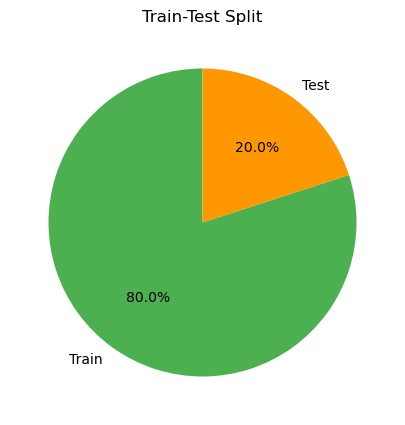

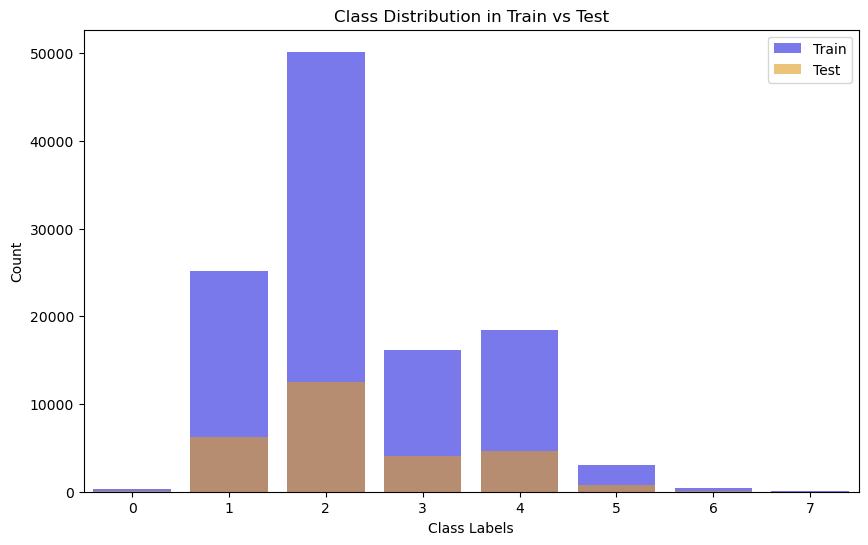

In [48]:
sizes = [len(X_train), len(X_test)]
labels = ['Train', 'Test']

plt.figure(figsize=(7, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#FF9800'])
plt.title('Train-Test Split')
plt.savefig(r"C:\Users\Nathalya Peralta\Downloads\thesis\test.png", dpi=300, bbox_inches='tight')

plt.show()

plt.figure(figsize=(10, 6))

import pandas as pd
train_labels = pd.Series(y_train).value_counts()
test_labels = pd.Series(y_test).value_counts()

sns.barplot(x=train_labels.index, y=train_labels.values, color='blue', alpha=0.6, label='Train')
sns.barplot(x=test_labels.index, y=test_labels.values, color='orange', alpha=0.6, label='Test')

plt.title('Class Distribution in Train vs Test')
plt.xlabel('Class Labels')
plt.ylabel('Count')
plt.legend()
plt.show()

In [49]:
results = {}

### Model Comparison

In [50]:
from sklearn.metrics import precision_score, recall_score
nb_model = GaussianNB()

acc_list, f1w_list, f1m_list, precw_list, precm_list, recw_list, recm_list = run_model(
    "Naive Bayes",
    nb_model,
    use_scaled=True
)

results['Naive Bayes'] = {
    "Accuracy": acc_list,
    "Weighted F1": f1w_list,
    "Macro F1": f1m_list,
    "Precision Weighted": precw_list,
    "Precision Macro": precm_list,
    "Recall Weighted": recw_list,
    "Recall Macro": recm_list
}


======= Naive Bayes =======

Split 1: Train samples=113756, Test samples=28440
Accuracy=0.418, Weighted F1=0.392, Macro F1=0.175
Confusion Matrix:
 [[   0   28   49    6    7    0    0    2]
 [   0 3104 3075   30   78    0    0    0]
 [   0 4013 7260  568  699    0    0    0]
 [   0  825 2145  471  589    0    0   21]
 [   0  817 2216  416 1043    0    0  107]
 [   0  156  366   73  149    0    0   17]
 [   0   22   52    8   16    0    0    1]
 [   0    3    5    0    2    0    0    1]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        92
           1       0.35      0.49      0.41      6287
           2       0.48      0.58      0.52     12540
           3       0.30      0.12      0.17      4051
           4       0.40      0.23      0.29      4599
           5       0.00      0.00      0.00       761
           6       0.00      0.00      0.00        99
           7       0.01      0.09      0.01      

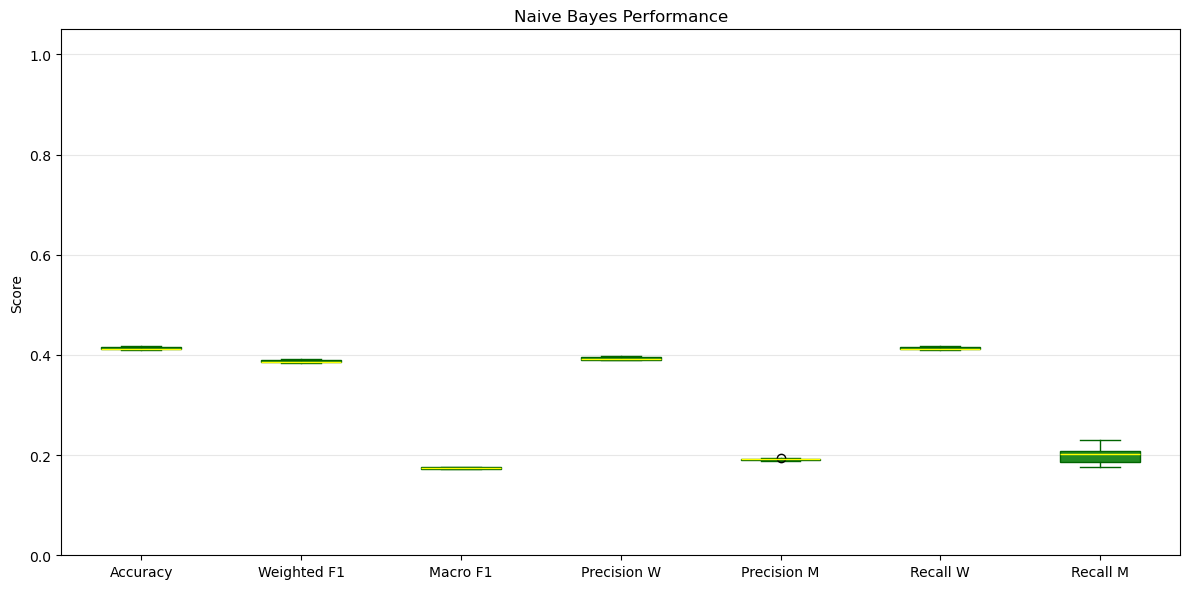

In [51]:
metrics_data = [
    acc_list,
    f1w_list,
    f1m_list,
    precw_list,
    precm_list,
    recw_list,
    recm_list
]
metrics_labels = [
    "Accuracy",
    "Weighted F1",
    "Macro F1",
    "Precision W",
    "Precision M",
    "Recall W",
    "Recall M"
]

plt.figure(figsize=(12,6))
plt.boxplot(
    metrics_data,
    labels=metrics_labels,
    patch_artist=True,
    boxprops=dict(facecolor='forestgreen', color='darkgreen'),
    medianprops=dict(color='yellow'),
    whiskerprops=dict(color='darkgreen'),
    capprops=dict(color='darkgreen')
)

plt.title("Naive Bayes Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

acc_list, f1w_list, f1m_list, precw_list, precm_list, recw_list, recm_list = run_model(
    "Random Forest",
    rf_model,
    use_scaled=False
)

results['Random Forest'] = {
    "Accuracy": acc_list,
    "Weighted F1": f1w_list,
    "Macro F1": f1m_list,
    "Precision Weighted": precw_list,
    "Precision Macro": precm_list,
    "Recall Weighted": recw_list,
    "Recall Macro": recm_list
}


======= Random Forest =======

Split 1: Train samples=113756, Test samples=28440
Accuracy=0.584, Weighted F1=0.562, Macro F1=0.286
Confusion Matrix:
 [[   2   11   16    4   58    1    0    0]
 [   1 2862 3215  113   94    2    0    0]
 [   0 2009 9313  971  236   10    1    0]
 [   1  219 2525  959  333   11    3    0]
 [  12  178  620  238 3450   97    4    0]
 [   1   32  120   46  529   31    2    0]
 [   0    5   27    6   51   10    0    0]
 [   0    3    3    0    4    1    0    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.12      0.02      0.04        92
           1       0.54      0.46      0.49      6287
           2       0.59      0.74      0.66     12540
           3       0.41      0.24      0.30      4051
           4       0.73      0.75      0.74      4599
           5       0.19      0.04      0.07       761
           6       0.00      0.00      0.00        99
           7       0.00      0.00      0.00    

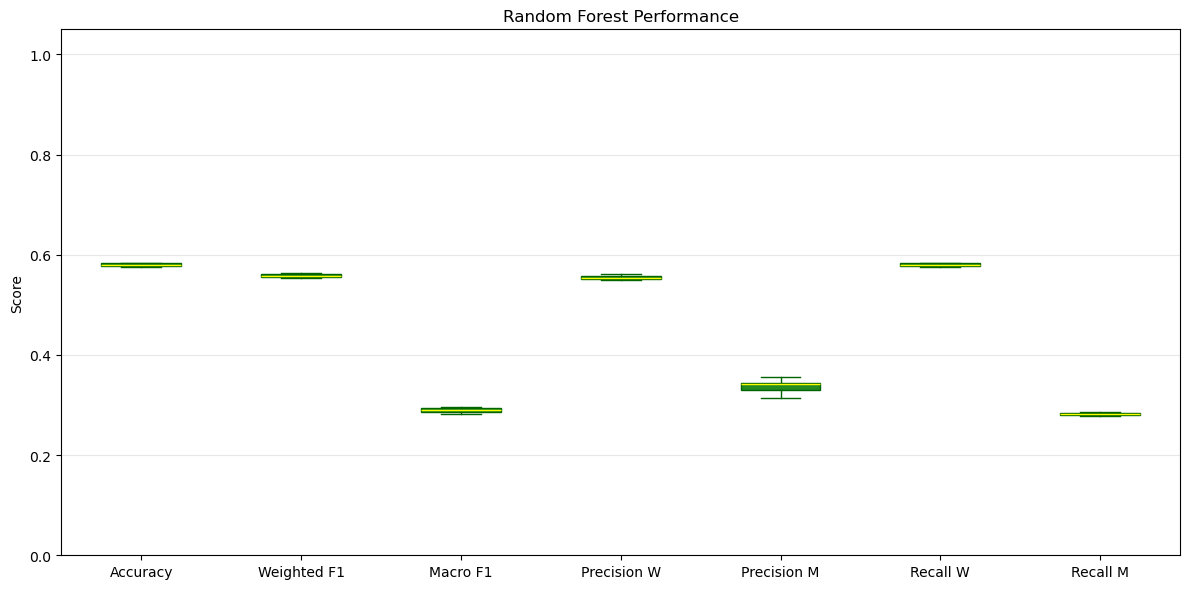

In [53]:
metrics_data = [
    acc_list,
    f1w_list,
    f1m_list,
    precw_list,
    precm_list,
    recw_list,
    recm_list
]
metrics_labels = [
    "Accuracy",
    "Weighted F1",
    "Macro F1",
    "Precision W",
    "Precision M",
    "Recall W",
    "Recall M"
]

plt.figure(figsize=(12,6))
plt.boxplot(
    metrics_data,
    labels=metrics_labels,
    patch_artist=True,
    boxprops=dict(facecolor='forestgreen', color='darkgreen'),
    medianprops=dict(color='yellow'),
    whiskerprops=dict(color='darkgreen'),
    capprops=dict(color='darkgreen')
)

plt.title("Random Forest Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
xgb_model = XGBClassifier(
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

acc_list, f1w_list, f1m_list, precw_list, precm_list, recw_list, recm_list = run_model(
    "XGBoost",
    xgb_model,
    use_scaled=False
)

results['XGBoost'] = {
    "Accuracy": acc_list,
    "Weighted F1": f1w_list,
    "Macro F1": f1m_list,
    "Precision Weighted": precw_list,
    "Precision Macro": precm_list,
    "Recall Weighted": recw_list,
    "Recall Macro": recm_list
}


======= XGBoost =======

Split 1: Train samples=113756, Test samples=28440


C:\Users\Nathalya.DESKTOP-HGJLIEN\anaconda\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:59:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy=0.626, Weighted F1=0.586, Macro F1=0.307
Confusion Matrix:
 [[    4     2     5     1    80     0     0     0]
 [    0  2682  3528    14    63     0     0     0]
 [    0  1509 10549   387    94     1     0     0]
 [    0    83  2988   650   326     2     1     1]
 [    3    41   458   178  3881    34     4     0]
 [    0    14    76    33   614    22     2     0]
 [    0     2    14     4    64    11     4     0]
 [    0     1     3     0     7     0     0     0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.04      0.08        92
           1       0.62      0.43      0.51      6287
           2       0.60      0.84      0.70     12540
           3       0.51      0.16      0.24      4051
           4       0.76      0.84      0.80      4599
           5       0.31      0.03      0.05       761
           6       0.36      0.04      0.07        99
           7       0.00      0.00      0.00        11

    accura

C:\Users\Nathalya.DESKTOP-HGJLIEN\anaconda\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:59:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy=0.626, Weighted F1=0.586, Macro F1=0.303
Confusion Matrix:
 [[    1     6     2     0    82     1     0     0]
 [    0  2663  3558    13    52     1     0     0]
 [    0  1426 10585   379   148     2     0     0]
 [    1    99  2976   672   301     1     1     0]
 [    5    48   484   176  3846    37     3     0]
 [    0    14    84    27   605    22     8     1]
 [    0     2    13     2    71     5     6     0]
 [    0     0     1     0     9     1     0     0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.14      0.01      0.02        92
           1       0.63      0.42      0.51      6287
           2       0.60      0.84      0.70     12540
           3       0.53      0.17      0.25      4051
           4       0.75      0.84      0.79      4599
           5       0.31      0.03      0.05       761
           6       0.33      0.06      0.10        99
           7       0.00      0.00      0.00        11

    accura

...

Accuracy=0.623, Weighted F1=0.583, Macro F1=0.309
Confusion Matrix:
 [[    3     3     0     0    86     0     0     0]
 [    0  2699  3513    26    48     0     1     0]
 [    0  1544 10528   355   112     1     0     0]
 [    1   123  3018   605   301     3     0     0]
 [    1    37   490   193  3845    26     7     0]
 [    0    20    86    28   586    35     6     0]
 [    0     1    12     3    67    10     6     0]
 [    0     0     1     0     9     1     0     0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.03      0.06        92
           1       0.61      0.43      0.50      6287
           2       0.60      0.84      0.70     12540
           3       0.50      0.15      0.23      4051
           4       0.76      0.84      0.80      4599
           5       0.46      0.05      0.08       761
           6       0.30      0.06      0.10        99
           7       0.00      0.00      0.00        11

    accura

C:\Users\Nathalya.DESKTOP-HGJLIEN\anaconda\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:00:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy=0.627, Weighted F1=0.588, Macro F1=0.308
Confusion Matrix:
 [[    4     4     1     0    83     0     0     0]
 [    0  2694  3523    17    53     0     0     0]
 [    0  1488 10573   355   118     3     3     0]
 [    0    98  2973   663   306     9     2     0]
 [    2    30   473   178  3883    28     5     0]
 [    0    14    97    20   600    25     5     0]
 [    0     1    11     2    67    13     4     1]
 [    0     1     1     1     8     0     0     0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.04      0.08        92
           1       0.62      0.43      0.51      6287
           2       0.60      0.84      0.70     12540
           3       0.54      0.16      0.25      4051
           4       0.76      0.84      0.80      4599
           5       0.32      0.03      0.06       761
           6       0.21      0.04      0.07        99
           7       0.00      0.00      0.00        11

    accura

C:\Users\Nathalya.DESKTOP-HGJLIEN\anaconda\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:00:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy=0.626, Weighted F1=0.585, Macro F1=0.295
Confusion Matrix:
 [[    0     4     2     0    86     0     0     0]
 [    0  2615  3612    13    46     1     0     0]
 [    0  1409 10656   364   110     1     0     0]
 [    0   111  2981   650   306     3     0     0]
 [    3    42   470   183  3864    34     3     0]
 [    0    18    86    31   596    21     9     0]
 [    0     0    13     2    70     9     4     1]
 [    0     0     3     0     6     1     1     0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        92
           1       0.62      0.42      0.50      6287
           2       0.60      0.85      0.70     12540
           3       0.52      0.16      0.25      4051
           4       0.76      0.84      0.80      4599
           5       0.30      0.03      0.05       761
           6       0.24      0.04      0.07        99
           7       0.00      0.00      0.00        11

    accura

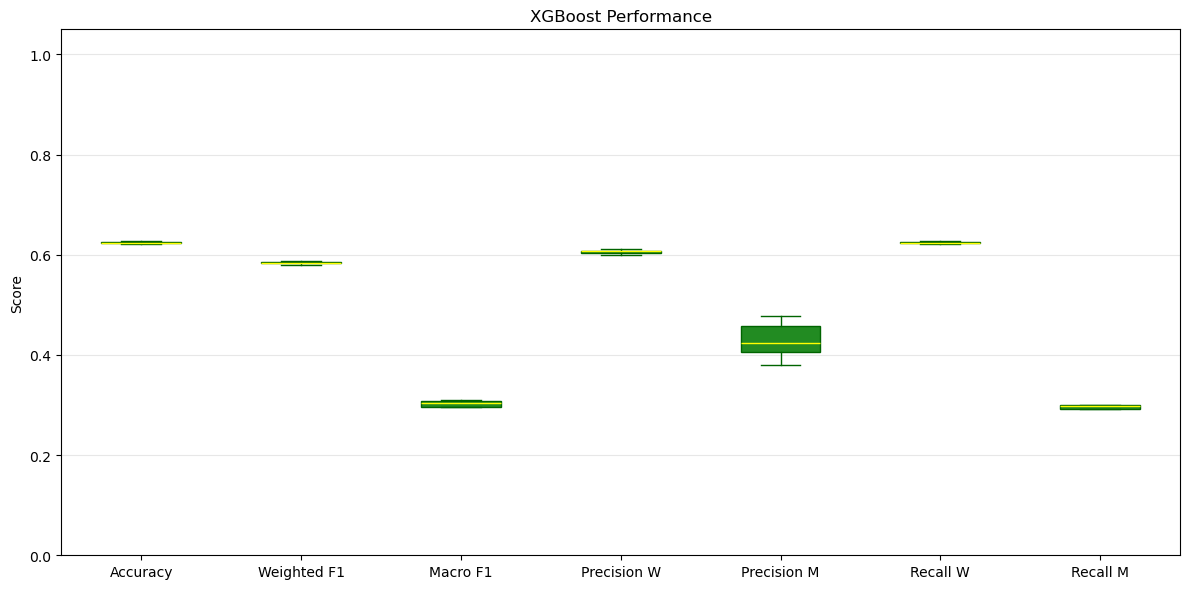

In [55]:
metrics_data = [
    acc_list,
    f1w_list,
    f1m_list,
    precw_list,
    precm_list,
    recw_list,
    recm_list
]
metrics_labels = [
    "Accuracy",
    "Weighted F1",
    "Macro F1",
    "Precision W",
    "Precision M",
    "Recall W",
    "Recall M"
]

plt.figure(figsize=(12,6))
plt.boxplot(
    metrics_data,
    labels=metrics_labels,
    patch_artist=True,
    boxprops=dict(facecolor='forestgreen', color='darkgreen'),
    medianprops=dict(color='yellow'),
    whiskerprops=dict(color='darkgreen'),
    capprops=dict(color='darkgreen')
)

plt.title("XGBoost Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
knn_model = KNeighborsClassifier(n_neighbors=5)

acc_list, f1w_list, f1m_list, precw_list, precm_list, recw_list, recm_list = run_model(
    "KNN",
    knn_model,
    use_scaled=True
)

results['KNN'] = {
    "Accuracy": acc_list,
    "Weighted F1": f1w_list,
    "Macro F1": f1m_list,
    "Precision Weighted": precw_list,
    "Precision Macro": precm_list,
    "Recall Weighted": recw_list,
    "Recall Macro": recm_list
}


======= KNN =======

Split 1: Train samples=113756, Test samples=28440
Accuracy=0.534, Weighted F1=0.517, Macro F1=0.264
Confusion Matrix:
 [[   4   14   21    5   47    1    0    0]
 [   5 3110 2922  119  128    3    0    0]
 [   7 2787 8435  930  367   14    0    0]
 [   3  375 2461  830  374    8    0    0]
 [  11  353 1021  347 2785   82    0    0]
 [   2   78  145   65  443   27    1    0]
 [   0   15   28    6   48    2    0    0]
 [   0    4    2    0    4    1    0    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.12      0.04      0.06        92
           1       0.46      0.49      0.48      6287
           2       0.56      0.67      0.61     12540
           3       0.36      0.20      0.26      4051
           4       0.66      0.61      0.63      4599
           5       0.20      0.04      0.06       761
           6       0.00      0.00      0.00        99
           7       0.00      0.00      0.00        11

  

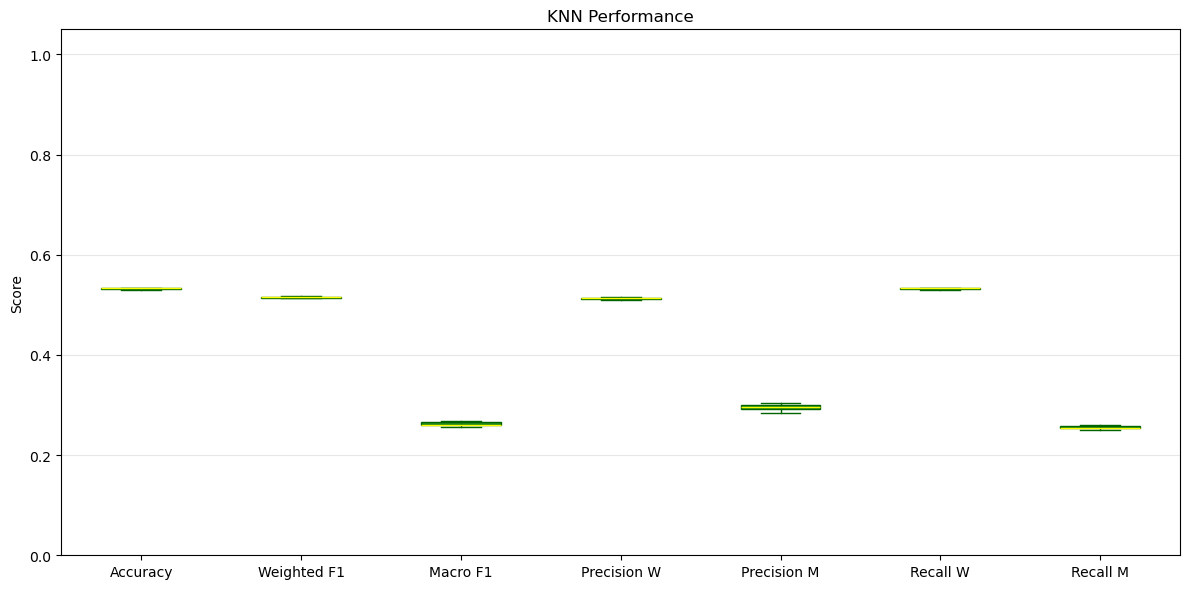

In [57]:
metrics_data = [
    acc_list,
    f1w_list,
    f1m_list,
    precw_list,
    precm_list,
    recw_list,
    recm_list
]
metrics_labels = [
    "Accuracy",
    "Weighted F1",
    "Macro F1",
    "Precision W",
    "Precision M",
    "Recall W",
    "Recall M"
]

plt.figure(figsize=(12,6))
plt.boxplot(
    metrics_data,
    labels=metrics_labels,
    patch_artist=True,
    boxprops=dict(facecolor='forestgreen', color='darkgreen'),
    medianprops=dict(color='yellow'),
    whiskerprops=dict(color='darkgreen'),
    capprops=dict(color='darkgreen')
)

plt.title("KNN Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
svm_model = SVC(
    kernel='rbf',
    probability=False,
    random_state=42,
    C=1.0,
    gamma='scale'
)

acc_list, f1w_list, f1m_list, precw_list, precm_list, recw_list, recm_list = run_model(
    "SVM",
    svm_model,
    use_scaled=True,
    max_train_samples=50000
)

results['SVM'] = {
    "Accuracy": acc_list,
    "Weighted F1": f1w_list,
    "Macro F1": f1m_list,
    "Precision Weighted": precw_list,
    "Precision Macro": precm_list,
    "Recall Weighted": recw_list,
    "Recall Macro": recm_list
}


======= SVM =======

Split 1: Train samples=50000, Test samples=28440
Accuracy=0.525, Weighted F1=0.452, Macro F1=0.197
Confusion Matrix:
 [[    0    10    51     0    31     0     0     0]
 [    0  1241  5005     0    41     0     0     0]
 [    0   767 11392    96   285     0     0     0]
 [    0    89  3369   258   335     0     0     0]
 [    0   201  2272    93  2033     0     0     0]
 [    0    49   353    13   346     0     0     0]
 [    0     2    59     1    37     0     0     0]
 [    0     2     5     0     4     0     0     0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        92
           1       0.53      0.20      0.29      6287
           2       0.51      0.91      0.65     12540
           3       0.56      0.06      0.11      4051
           4       0.65      0.44      0.53      4599
           5       0.00      0.00      0.00       761
           6       0.00      0.00      0.00     

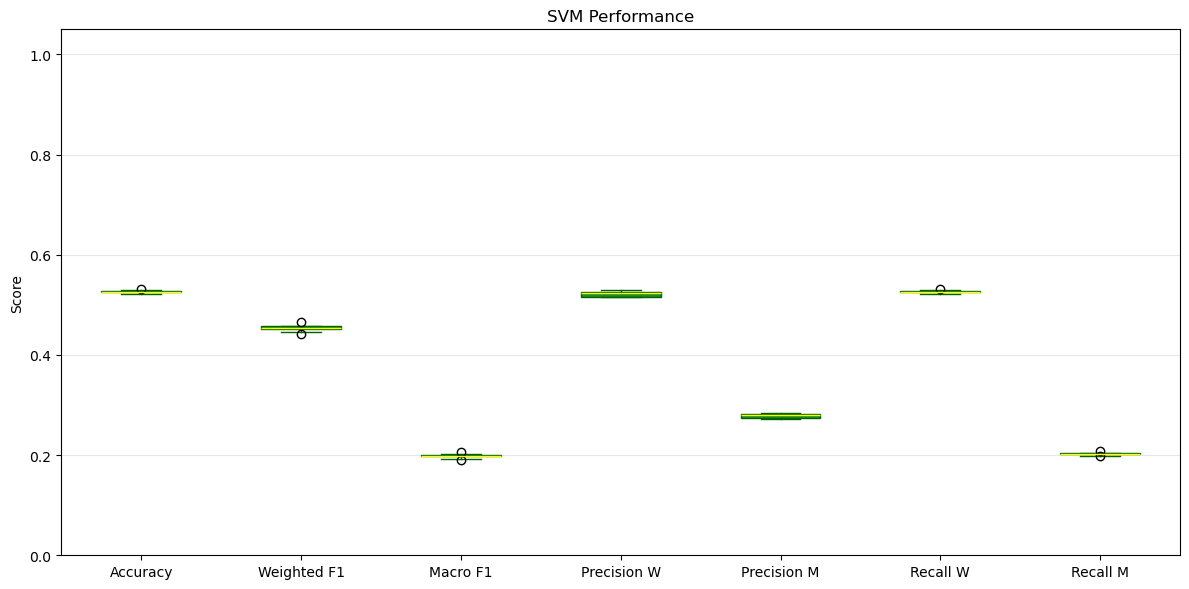

In [59]:
metrics_data = [
    acc_list,
    f1w_list,
    f1m_list,
    precw_list,
    precm_list,
    recw_list,
    recm_list
]
metrics_labels = [
    "Accuracy",
    "Weighted F1",
    "Macro F1",
    "Precision W",
    "Precision M",
    "Recall W",
    "Recall M"
]

plt.figure(figsize=(12,6))
plt.boxplot(
    metrics_data,
    labels=metrics_labels,
    patch_artist=True,
    boxprops=dict(facecolor='forestgreen', color='darkgreen'),
    medianprops=dict(color='yellow'),
    whiskerprops=dict(color='darkgreen'),
    capprops=dict(color='darkgreen')
)

plt.title("SVM Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
agg_results = []

for name, metrics in results.items():
    acc_list = metrics['Accuracy']
    f1w_list = metrics['Weighted F1']
    f1m_list = metrics['Macro F1']
    precw_list = metrics['Precision Weighted']
    precm_list = metrics['Precision Macro']
    recw_list = metrics['Recall Weighted']
    recm_list = metrics['Recall Macro']
    
    agg_results.append({
        'Model': name,
        'Accuracy (Mean ± Std)': f"{np.mean(acc_list):.3f} ± {np.std(acc_list):.3f}",
        'Precision W (Mean ± Std)': f"{np.mean(precw_list):.3f} ± {np.std(precw_list):.3f}",
        'Precision M (Mean ± Std)': f"{np.mean(precm_list):.3f} ± {np.std(precm_list):.3f}",
        'Recall W (Mean ± Std)': f"{np.mean(recw_list):.3f} ± {np.std(recw_list):.3f}",
        'Recall M (Mean ± Std)': f"{np.mean(recm_list):.3f} ± {np.std(recm_list):.3f}",
        'F1-score W (Mean ± Std)': f"{np.mean(f1w_list):.3f} ± {np.std(f1w_list):.3f}",
        'F1-score M (Mean ± Std)': f"{np.mean(f1m_list):.3f} ± {np.std(f1m_list):.3f}",
    })

results_summary_df = pd.DataFrame(agg_results)
results_summary_df

,Model,Accuracy (Mean ± Std),Precision W (Mean ± Std),Precision M (Mean ± Std),Recall W (Mean ± Std),Recall M (Mean ± Std),F1-score W (Mean ± Std),F1-score M (Mean ± Std)
0,Naive Bayes,0.413 ± 0.002,0.393 ± 0.003,0.192 ± 0.002,0.413 ± 0.002,0.200 ± 0.015,0.387 ± 0.002,0.174 ± 0.002
1,Random Forest,0.580 ± 0.003,0.555 ± 0.004,0.337 ± 0.012,0.580 ± 0.003,0.282 ± 0.003,0.558 ± 0.003,0.290 ± 0.004
2,XGBoost,0.624 ± 0.002,0.606 ± 0.003,0.429 ± 0.031,0.624 ± 0.002,0.296 ± 0.004,0.584 ± 0.002,0.303 ± 0.006
3,KNN,0.533 ± 0.001,0.512 ± 0.002,0.295 ± 0.006,0.533 ± 0.001,0.255 ± 0.003,0.515 ± 0.001,0.262 ± 0.004
4,SVM,0.526 ± 0.003,0.522 ± 0.005,0.278 ± 0.004,0.526 ± 0.003,0.202 ± 0.003,0.454 ± 0.006,0.199 ± 0.004


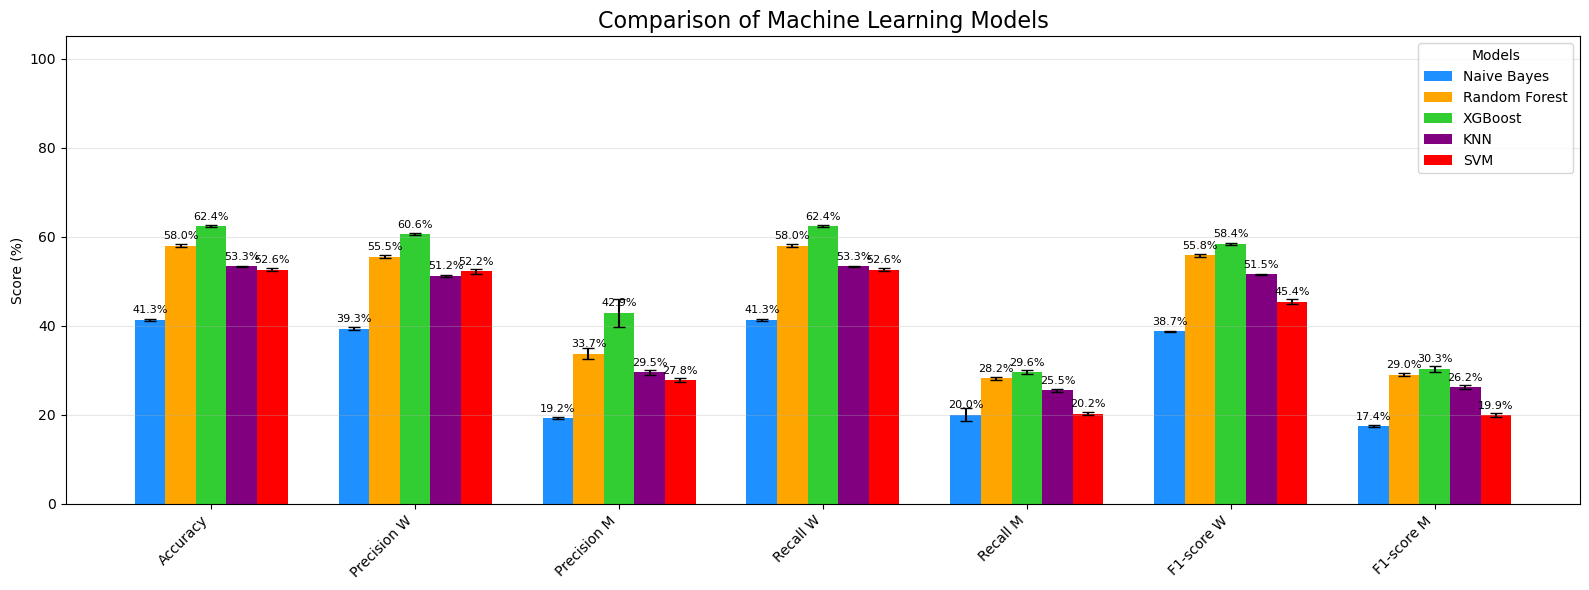

In [61]:
metrics_names = [
    'Accuracy', 'Precision W', 'Precision M', 
    'Recall W', 'Recall M', 'F1-score W', 'F1-score M'
]
models = results_summary_df['Model'].tolist()

metric_means = {}
metric_stds = {}
for metric in metrics_names:
    mean_list = []
    std_list = []
    for val in results_summary_df[f'{metric} (Mean ± Std)']:
        mean, std = val.split('±')
        mean_list.append(float(mean.strip()))
        std_list.append(float(std.strip()))
    metric_means[metric] = mean_list
    metric_stds[metric] = std_list

x = np.arange(len(metrics_names)) 
width = 0.15  

plt.figure(figsize=(16,6))

colors = ['dodgerblue', 'orange', 'limegreen', 'purple', 'red']  

for i, model in enumerate(models):
    means = [metric_means[m][i]*100 for m in metrics_names] 
    stds = [metric_stds[m][i]*100 for m in metrics_names]
    bars = plt.bar(x + i*width, means, width, yerr=stds, capsize=4, color=colors[i], label=model)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2, 
            height + 1, 
            f'{height:.1f}%', 
            ha='center', va='bottom', fontsize=8
        )

plt.xticks(x + width*2, metrics_names, rotation=45, ha='right')
plt.ylabel("Score (%)")
plt.ylim(0, 105)
plt.title("Comparison of Machine Learning Models", fontsize=16)
plt.legend(title="Models")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# XGBoost

In [62]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in sss.split(X, y):
    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    else:
        X_train, X_test = X[train_idx], X[test_idx]
    
    if isinstance(y, pd.Series):
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    else: 
        y_train, y_test = y[train_idx], y[test_idx]

In [63]:
xgb_eval = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_eval.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [64]:
y_pred = xgb_eval.predict(X_test)
y_prob = xgb_eval.predict_proba(X_test)

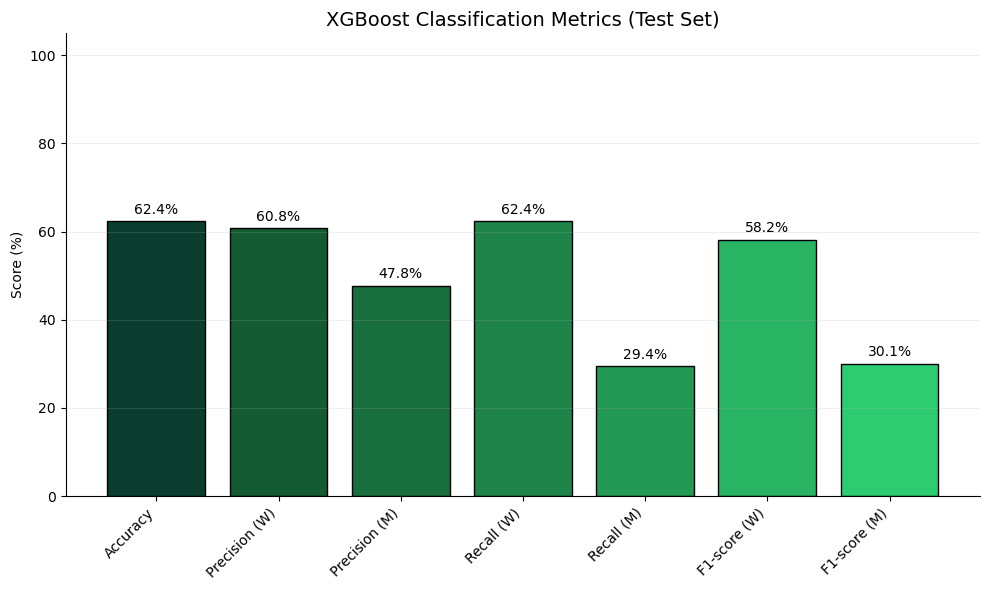

In [65]:
accuracy = accuracy_score(y_test, y_pred)
precision_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
precision_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
recall_m = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)

metrics = {
    "Accuracy": accuracy,
    "Precision (W)": precision_w,
    "Precision (M)": precision_m,
    "Recall (W)": recall_w,
    "Recall (M)": recall_m,
    "F1-score (W)": f1_w,
    "F1-score (M)": f1_m
}

colors = [
    '#0b3d2e', 
    '#145a32',
    '#196f3d',
    '#1e8449',
    '#229954',
    '#28b463',
    '#2ecc71'   
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    metrics.keys(),
    [v*100 for v in metrics.values()],
    color=colors,
    edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.ylim(0, 105)
plt.ylabel("Score (%)")
plt.title("XGBoost Classification Metrics (Test Set)", fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.2)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

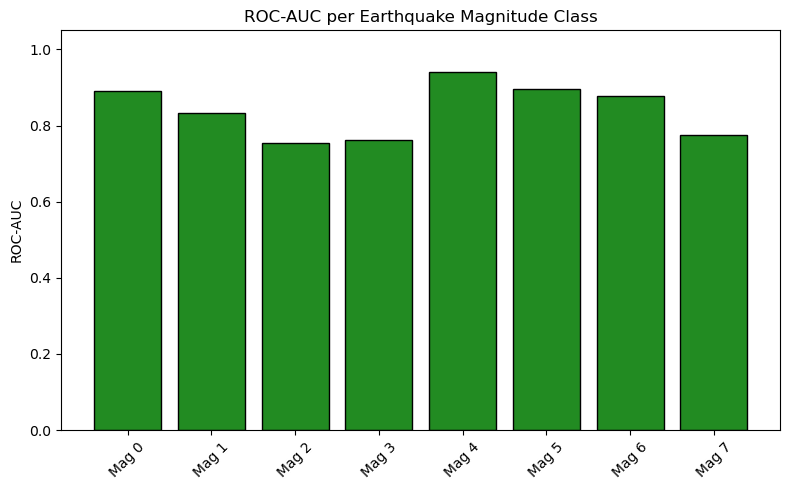

In [67]:
from sklearn.metrics import roc_auc_score
classes = xgb_eval.classes_
roc_auc_results = {}
for i, cls in enumerate(classes):
    y_true_bin = (y_test == cls).astype(int)
    y_score = y_prob[:, i]
    roc_auc_results[f"Mag {cls}"] = roc_auc_score(y_true_bin, y_score)

plt.figure(figsize=(8,5))
plt.bar(
    roc_auc_results.keys(),
    roc_auc_results.values(),
    color="forestgreen",
    edgecolor="black"
)
plt.ylabel("ROC-AUC")
plt.ylim(0, 1.05)
plt.title("ROC-AUC per Earthquake Magnitude Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[f"Mag {c}" for c in classes],
    yticklabels=[f"Mag {c}" for c in classes]
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix – XGBoost (Test Set)")
plt.tight_layout()
plt.show()

In [ ]:
xgb_full = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
xgb_full.fit(X, y)

y_prob_full = xgb_full.predict_proba(X)
classes = xgb_full.classes_

prob_df = pd.DataFrame(
    y_prob_full,
    columns=[f"Mag {c}" for c in classes]
)
prob_df["Region"] = df["region"]

In [ ]:
region_prob = prob_df.groupby("Region").mean().reset_index()

In [ ]:
mag_cols = [c for c in region_prob.columns if c != 'Region']

for _, row in region_prob.iterrows():
    region = row['Region']
    probs = row[mag_cols].values

    plt.figure(figsize=(8,5))
    bars = plt.bar(
        mag_cols,
        probs,
        color='forestgreen',
        edgecolor='black',
        width=0.7
    )

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.ylabel("Probability")
    plt.xlabel("Magnitude Class")
    plt.ylim(0, 1)
    plt.title(f"Earthquake Magnitude Probability Distribution\n{region}")

    # Clean look (no grid, remove top/right spines)
    plt.grid(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()

    plt.show()